In [1]:
import os, sqlite3, time, json
from datetime import datetime

import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_recall_fscore_support)

BASE_DIR = os.getcwd()                       # change this if your dataset is somewhere else
TRAIN_DIR = os.path.join(BASE_DIR, "dataset", "train")
TEST_DIR = os.path.join(BASE_DIR, "dataset", "test")
MODELS_DIR = os.path.join(BASE_DIR, "models")
PROCESSED_DIR = os.path.join(BASE_DIR, "processed")
DB_DIR = os.path.join(BASE_DIR, "database")
UPLOAD_DIR = os.path.join(BASE_DIR, "uploads")
MODEL_PATH = os.path.join(MODELS_DIR, "waste_model.pkl")
DB_PATH = os.path.join(DB_DIR, "waste.db")
for d in (MODELS_DIR, PROCESSED_DIR, DB_DIR, UPLOAD_DIR):
    os.makedirs(d, exist_ok=True)

CLASS_NAMES = ["Glass", "Metal", "Paper", "Plastic"]   # labels 0,1,2,3
IMAGE_SIZE = (224, 224)
FEATURE_DIM = 128
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
print("Working folder:", BASE_DIR)

Working folder: C:\Users\vaish\Documents


In [2]:
def read_image_bgr(path):
    """Read an image with OpenCV (works with spaces / non-ASCII Windows paths)."""
    data = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    return img


def apply_clahe(rgb):
    """CLAHE contrast enhancement on the lightness channel (LAB colour space)."""
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_channel = clahe.apply(l_channel)
    return cv2.cvtColor(cv2.merge((l_channel, a_channel, b_channel)), cv2.COLOR_LAB2RGB)


def preprocess_steps(path):
    """Run the full pipeline and return every intermediate stage (used for figures)."""
    bgr = read_image_bgr(path)                                        # 1. read
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)                        # 2. BGR -> RGB
    resized = cv2.resize(rgb, IMAGE_SIZE, interpolation=cv2.INTER_AREA)  # 3. 224x224
    blurred = cv2.GaussianBlur(resized, (5, 5), 0)                    # 4. noise reduction
    enhanced = apply_clahe(blurred)                                   # 5. contrast
    normalized = enhanced.astype(np.float32) / 255.0                  # 6. [0, 1]
    return {
        "original": rgb,
        "resized": resized,
        "blurred": blurred,
        "enhanced": enhanced,
        "normalized": normalized,
    }


def preprocess_image(path):
    """Return a 224x224x3 float32 RGB image with values in [0, 1]."""
    return preprocess_steps(path)["normalized"]

In [3]:
FEATURE_GROUPS = [
    ("RGB histogram", 24),
    ("Sobel gradients", 20),
    ("Edge energy", 4),
    ("Texture statistics", 25),
    ("Spatial blocks", 48),
    ("Brightness stats", 7),
]
assert sum(size for _, size in FEATURE_GROUPS) == FEATURE_DIM

EPS = 1e-8


def _skew_kurtosis(values):
    mean, std = float(np.mean(values)), float(np.std(values))
    if std < 1e-6:
        return 0.0, 0.0
    z = (values - mean) / std
    skew = float(np.clip(np.mean(z ** 3), -10, 10))
    kurt = float(np.clip(np.mean(z ** 4) - 3.0, -10, 10))
    return skew, kurt


def _normalized_hist(values, bins, value_range):
    hist, _ = np.histogram(values, bins=bins, range=value_range)
    return hist.astype(np.float32) / (hist.sum() + EPS)


def extract_features(img):
    """img: 224x224x3 float32 RGB in [0,1]. Returns float32 vector of length 128."""
    img = np.asarray(img, dtype=np.float32)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray8 = np.clip(gray * 255, 0, 255).astype(np.uint8)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hsv[:, :, 0] /= 360.0                      # hue 0-360 -> 0-1

    feats = []

    # 1) RGB colour histograms (24)
    for c in range(3):
        feats.extend(_normalized_hist(img[:, :, c], 8, (0, 1)))

    # 2) Sobel gradients (20)
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx ** 2 + gy ** 2)
    ang = np.arctan2(gy, gx)
    orient_hist, _ = np.histogram(ang, bins=8, range=(-np.pi, np.pi), weights=mag)
    feats.extend(orient_hist.astype(np.float32) / (orient_hist.sum() + EPS))   # 8
    feats.extend(_normalized_hist(np.clip(mag, 0, 2), 8, (0, 2)))              # 8
    feats.extend([np.mean(np.abs(gx)), np.mean(np.abs(gy)), np.std(gx), np.std(gy)])  # 4

    # 3) Edge energy (4)
    edges = cv2.Canny(gray8, 100, 200)
    feats.append(float(edges.mean()) / 255.0)             # edge density
    feats.append(float(np.mean(mag ** 2)))                # gradient energy
    feats.append(float(cv2.Laplacian(gray, cv2.CV_32F).var()))   # sharpness
    feats.append(float(np.percentile(mag, 95)))           # strong-edge level

    # 4) Texture statistics (25)
    skew, kurt = _skew_kurtosis(gray)
    gray_hist = _normalized_hist(gray, 32, (0, 1))
    entropy = float(-np.sum(gray_hist * np.log2(gray_hist + EPS)))
    feats.extend([gray.mean(), gray.std(), skew, kurt, entropy])        # 5
    feats.extend(img.reshape(-1, 3).mean(axis=0))                       # 3
    feats.extend(img.reshape(-1, 3).std(axis=0))                        # 3
    feats.extend(hsv.reshape(-1, 3).mean(axis=0))                       # 3
    feats.extend(hsv.reshape(-1, 3).std(axis=0))                        # 3
    feats.extend(_normalized_hist(gray, 8, (0, 1)))                     # 8

    # 5) Spatial / block features: 4x4 grid x 3 values (48)
    h, w = gray.shape
    bh, bw = h // 4, w // 4
    for i in range(4):
        for j in range(4):
            g = gray[i * bh:(i + 1) * bh, j * bw:(j + 1) * bw]
            e = mag[i * bh:(i + 1) * bh, j * bw:(j + 1) * bw]
            feats.extend([g.mean(), g.std(), e.mean()])

    # 6) Brightness / shine statistics (7)
    feats.extend(np.percentile(gray, [10, 25, 50, 75, 90]))             # 5
    feats.append(float((hsv[:, :, 1] > 0.5).mean()))                    # saturated pixels
    feats.append(float((gray > 0.9).mean()))                            # specular highlights

    vector = np.array(feats, dtype=np.float32)
    assert vector.shape == (FEATURE_DIM,), f"Feature length is {vector.shape[0]}, expected {FEATURE_DIM}"
    return vector

In [4]:
def find_class_folder(split_dir, class_name):
    """Find the folder for a class ignoring upper/lower case (Glass == glass)."""
    if not os.path.isdir(split_dir):
        return None
    for entry in os.listdir(split_dir):
        full = os.path.join(split_dir, entry)
        if os.path.isdir(full) and entry.lower() == class_name.lower():
            return full
    return None


def list_images(folder):
    return sorted(
        os.path.join(folder, f) for f in os.listdir(folder)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    )


def load_features(split_dir, log=print):
    """Return (X, y). y holds 0=Glass, 1=Metal, 2=Paper, 3=Plastic."""
    X, y = [], []
    for label, class_name in enumerate(CLASS_NAMES):
        folder = find_class_folder(split_dir, class_name)
        if folder is None:
            log(f"[WARNING] Folder for class '{class_name}' not found in {split_dir}")
            continue
        paths = list_images(folder)
        log(f"Loading {len(paths):5d} images for class {class_name}")
        for count, path in enumerate(paths, 1):
            try:
                X.append(extract_features(preprocess_image(path)))
                y.append(label)
            except Exception as exc:                      # unreadable / corrupt image
                log(f"  skipped {os.path.basename(path)}: {exc}")
            if count % 200 == 0:
                log(f"  ... {count}/{len(paths)}")
    if not X:
        return np.empty((0, FEATURE_DIM), dtype=np.float32), np.empty((0,), dtype=np.int64)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

In [5]:
rng = np.random.default_rng(1)

def make_image(label):
    img = rng.integers(0, 50, (240, 320, 3), dtype=np.uint8)
    x, y = int(rng.integers(60, 260)), int(rng.integers(60, 180))
    if label == "Glass":
        img[:, :, 1] = np.clip(img[:, :, 1] + 90, 0, 255)
        cv2.circle(img, (x, y), int(rng.integers(40, 80)), (230, 255, 230), -1)
    elif label == "Metal":
        img[:] = np.clip(140 + rng.integers(0, 40, img.shape), 0, 255)
        cv2.line(img, (0, int(rng.integers(0, 240))), (320, int(rng.integers(0, 240))), (255, 255, 255), 5)
    elif label == "Paper":
        img[:] = np.clip(200 + rng.integers(0, 40, img.shape), 0, 255)
        for r in range(0, 240, int(rng.integers(20, 40))):
            cv2.line(img, (0, r), (320, r), (120, 120, 120), 1)
    else:
        img[:, :, 2] = np.clip(img[:, :, 2] + 130, 0, 255)
        cv2.rectangle(img, (x - 50, y - 40), (x + 50, y + 40), (0, 180, 255), -1)
    return img

for split, count in (("train", 40), ("test", 10)):
    for label in CLASS_NAMES:
        folder = os.path.join(BASE_DIR, "dataset", split, label)
        os.makedirs(folder, exist_ok=True)
        for i in range(count):
            cv2.imwrite(os.path.join(folder, f"demo_{i:03d}.jpg"), make_image(label))
print("Demo images created.")

Demo images created.


Loading    40 images for class Glass
Loading    40 images for class Metal
Loading    40 images for class Paper
Loading    40 images for class Plastic

Feature matrix shape: (160, 128)
  Glass   : 40 images
  Metal   : 40 images
  Paper   : 40 images
  Plastic : 40 images
Feature extraction time: 8.9 s

Iteration 1, loss = 1.72318769
Iteration 2, loss = 1.50292766
Iteration 3, loss = 1.31088531
Iteration 4, loss = 1.14733362
Iteration 5, loss = 1.00794506
Iteration 6, loss = 0.88893926
Iteration 7, loss = 0.78754199
Iteration 8, loss = 0.70041871
Iteration 9, loss = 0.62544984
Iteration 10, loss = 0.55852938
Iteration 11, loss = 0.49830499
Iteration 12, loss = 0.44471282
Iteration 13, loss = 0.39717561
Iteration 14, loss = 0.35474604
Iteration 15, loss = 0.31643051
Iteration 16, loss = 0.28147185
Iteration 17, loss = 0.24982607
Iteration 18, loss = 0.22129634
Iteration 19, loss = 0.19579250
Iteration 20, loss = 0.17303717
Iteration 21, loss = 0.15279935
Iteration 22, loss = 0.13487062
I

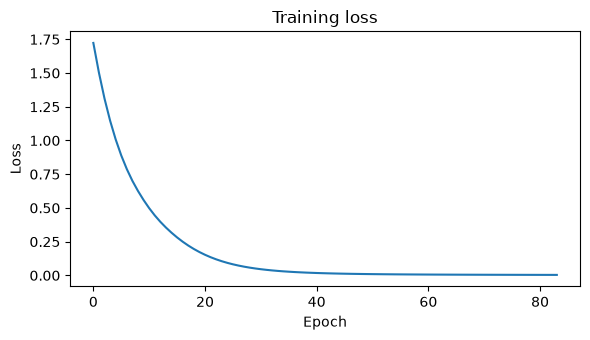

In [6]:
start = time.time()
X_train, y_train = load_features(TRAIN_DIR)
if len(X_train) == 0:
    raise SystemExit("No training images found. Put images in dataset/train/<Glass|Metal|Paper|Plastic>/")
np.save(os.path.join(PROCESSED_DIR, "features.npy"), X_train)
np.save(os.path.join(PROCESSED_DIR, "labels.npy"), y_train)
print("\nFeature matrix shape:", X_train.shape)
for label, name in enumerate(CLASS_NAMES):
    print(f"  {name:8s}: {int(np.sum(y_train == label))} images")
print(f"Feature extraction time: {time.time() - start:.1f} s\n")

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
                    alpha=0.001, max_iter=200, random_state=42, verbose=True)
model = Pipeline([("scaler", StandardScaler()), ("mlp", mlp)])
model.fit(X_train, y_train)

mlp = model.named_steps["mlp"]
print("\nEpochs run          :", mlp.n_iter_)
print("Final training loss :", round(mlp.loss_, 4))
print("Training accuracy   :", round(model.score(X_train, y_train) * 100, 2), "%")
joblib.dump(model, MODEL_PATH)
print("Model saved to", MODEL_PATH)

plt.figure(figsize=(6, 3.5))
plt.plot(mlp.loss_curve_); plt.title("Training loss"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout(); plt.show()

Loading    10 images for class Glass
Loading    10 images for class Metal
Loading    10 images for class Paper
Loading    10 images for class Plastic
Test images         : 40
Accuracy            : 100.00 %
Precision (weighted): 100.00 %
Recall    (weighted): 100.00 %
F1-score  (weighted): 100.00 %

              precision    recall  f1-score   support

       Glass       1.00      1.00      1.00        10
       Metal       1.00      1.00      1.00        10
       Paper       1.00      1.00      1.00        10
     Plastic       1.00      1.00      1.00        10

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



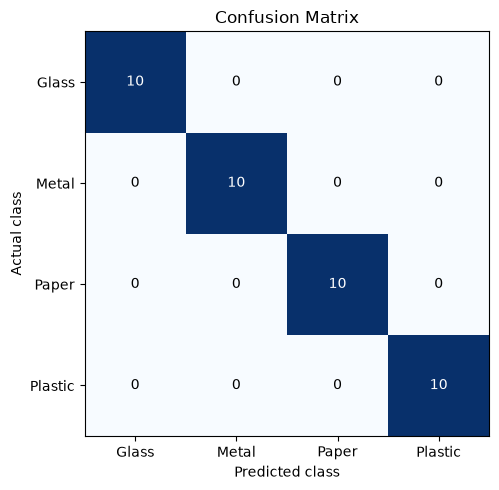

In [7]:
model = joblib.load(MODEL_PATH)
X_test, y_test = load_features(TEST_DIR)
if len(X_test) == 0:
    raise SystemExit("No test images found. Put images in dataset/test/<Glass|Metal|Paper|Plastic>/")

y_pred = model.predict(X_test)
labels = list(range(len(CLASS_NAMES)))
accuracy = accuracy_score(y_test, y_pred)
p_w, r_w, f_w, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
cm = confusion_matrix(y_test, y_pred, labels=labels)

print(f"Test images         : {len(y_test)}")
print(f"Accuracy            : {accuracy * 100:.2f} %")
print(f"Precision (weighted): {p_w * 100:.2f} %")
print(f"Recall    (weighted): {r_w * 100:.2f} %")
print(f"F1-score  (weighted): {f_w * 100:.2f} %\n")
print(classification_report(y_test, y_pred, labels=labels, target_names=CLASS_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted class"); ax.set_ylabel("Actual class"); ax.set_title("Confusion Matrix")
for i in range(4):
    for j in range(4):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.savefig(os.path.join(MODELS_DIR, "confusion_matrix.png"), dpi=150); plt.show()

In [8]:
def init_db():
    with sqlite3.connect(DB_PATH) as conn:
        conn.execute("""CREATE TABLE IF NOT EXISTS predictions (
                            id INTEGER PRIMARY KEY AUTOINCREMENT,
                            filename TEXT NOT NULL,
                            predicted_class TEXT NOT NULL,
                            confidence REAL NOT NULL,
                            timestamp TEXT NOT NULL)""")

def log_prediction(filename, predicted_class, confidence):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with sqlite3.connect(DB_PATH) as conn:
        conn.execute("INSERT INTO predictions (filename, predicted_class, confidence, timestamp) VALUES (?, ?, ?, ?)",
                     (filename, predicted_class, confidence, timestamp))
    return timestamp

def show_history(limit=20):
    with sqlite3.connect(DB_PATH) as conn:
        rows = conn.execute("SELECT id, filename, predicted_class, confidence, timestamp "
                            "FROM predictions ORDER BY id DESC LIMIT ?", (limit,)).fetchall()
    print(f"{'ID':>3}  {'Filename':30s} {'Class':8s} {'Conf %':>7}  Timestamp")
    for r in rows:
        print(f"{r[0]:>3}  {r[1][:30]:30s} {r[2]:8s} {r[3]:7.1f}  {r[4]}")
    if not rows:
        print("No predictions yet.")

init_db()
print("Database ready:", DB_PATH)

Database ready: C:\Users\vaish\Documents\database\waste.db


In [9]:
model = joblib.load(MODEL_PATH)

def classify_image(image_path, save_to_db=True):
    if not image_path or not os.path.exists(image_path):
        print("Image not found:", repr(image_path))
        print("Set TEST_IMAGE to a real image path, e.g. r\"dataset/test/Metal/metal1.jpg\"")
        return None

    with Image.open(image_path) as pil_image:          # Pillow checks it is a real image
        pil_image.verify()
    image = preprocess_image(image_path)
    features = extract_features(image).reshape(1, -1)
    probabilities = model.predict_proba(features)[0]

    percentages = {name: 0.0 for name in CLASS_NAMES}
    for class_index, prob in zip(model.classes_, probabilities):
        percentages[CLASS_NAMES[int(class_index)]] = round(float(prob) * 100, 1)
    predicted = max(percentages, key=percentages.get)
    confidence = percentages[predicted]
    if save_to_db:
        log_prediction(os.path.basename(image_path), predicted, confidence)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
    ax1.imshow(preprocess_steps(image_path)["original"]); ax1.axis("off")
    ax1.set_title(f"Prediction: {predicted}   Confidence: {confidence:.1f}%")
    ax2.barh(CLASS_NAMES, [percentages[c] for c in CLASS_NAMES], color="#66bb6a")
    ax2.set_xlim(0, 100); ax2.set_xlabel("Probability (%)"); ax2.set_title("Class probabilities")
    plt.tight_layout(); plt.show()
    print(f"Prediction: {predicted}\nConfidence: {confidence:.1f}%")
    print("Probabilities:", percentages)
    return predicted, confidence, percentages


# ---- choose the image to classify ----
TEST_IMAGE = ""        # put your own path here,